In [5]:
import json
import numpy as np
from pathlib import Path
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Find all result JSON files
results_dir = Path("../../results/text_classification/dynamics_experiments")
result_files = list(results_dir.glob("**/results_*.json"))

print(f"Found {len(result_files)} result files")

# Store all differences
all_differences = {
    'logits_mean': [],     # Mean absolute difference per dimension
    'logits_max': [],      # Max absolute difference across dimensions
    'probs_sum': [],       # Sum of absolute differences (L1 norm)
    'probs_mean': [],      # Mean absolute difference per dimension
    'probs_max': [],       # Max absolute difference across dimensions
    'experiment': [],
    'sample_idx': [],
    'iteration': []
}

# Process each result file
for result_file in result_files:
    
    with open(result_file, 'r') as f:
        data = json.load(f)
    
    experiment_name = result_file.parent.name
    
    # Process each sample
    for sample in data['samples']:
        sample_idx = sample['sample_idx']
        sgd_logits = np.array(sample['sgd_logits_history'])
        zo_logits = np.array(sample['zo_logits_history'])
        sgd_probs = np.array(sample['sgd_probs_history'])
        zo_probs = np.array(sample['zo_probs_history'])
        
        # Calculate absolute differences for each iteration
        for iteration in range(len(sgd_logits)):
            # Logits absolute differences
            logits_abs_diff = np.abs(sgd_logits[iteration] - zo_logits[iteration])
            logits_mean = logits_abs_diff.mean()
            logits_max = logits_abs_diff.max()
            
            # Probs absolute differences
            probs_abs_diff = np.abs(sgd_probs[iteration] - zo_probs[iteration])
            probs_sum = probs_abs_diff.sum()
            probs_mean = probs_abs_diff.mean()
            probs_max = probs_abs_diff.max()
            
            all_differences['logits_mean'].append(logits_mean)
            all_differences['logits_max'].append(logits_max)
            all_differences['probs_sum'].append(probs_sum)
            all_differences['probs_mean'].append(probs_mean)
            all_differences['probs_max'].append(probs_max)
            all_differences['experiment'].append(experiment_name)
            all_differences['sample_idx'].append(sample_idx)
            all_differences['iteration'].append(iteration)

# Create DataFrame
df = pd.DataFrame(all_differences)

# Extract number of perturbations and model size from experiment name
# Format: opt-{model}_{method}_{num_perturbations}
def extract_num_perturbations(exp_name):
    """Extract number of perturbations from experiment name."""
    parts = exp_name.split('_')
    if len(parts) >= 2:
        try:
            return int(parts[-1])  # Last part should be the number
        except ValueError:
            return None
    return None

def extract_model_size(exp_name):
    """Extract model size from experiment name."""
    # Format: opt-{model}_{method}_{num_perturbations}
    # e.g., opt-1.3b_bernoulli_1 -> 1.3b
    # e.g., opt-125m_bernoulli_1 -> 125m
    # e.g., opt-350m_bernoulli_1 -> 350m
    if exp_name.startswith('opt-'):
        parts = exp_name.split('_')
        if len(parts) > 0:
            model_part = parts[0].replace('opt-', '')
            return model_part
    return None

def extract_method(exp_name):
    """Extract perturbation method from experiment name."""
    # Format: opt-{model}_{method}_{num_perturbations}
    # e.g., opt-1.3b_bernoulli_1 -> bernoulli
    # e.g., opt-1.3b_gaussian_1 -> gaussian
    parts = exp_name.split('_')
    if len(parts) >= 2:
        return parts[1]  # Second part should be the method
    return None

df['num_perturbations'] = df['experiment'].apply(extract_num_perturbations)
df['model_size'] = df['experiment'].apply(extract_model_size)
df['method'] = df['experiment'].apply(extract_method)
df = df.dropna(subset=['num_perturbations', 'model_size', 'method'])  # Remove rows where we couldn't extract the values

# Get unique model sizes and methods
unique_model_sizes = sorted(df['model_size'].unique())
unique_methods = sorted(df['method'].unique())
color_map = {model: plt.cm.tab10(i) for i, model in enumerate(unique_model_sizes)}
line_styles = {'bernoulli': '-', 'gaussian': '--'}


Found 75 result files


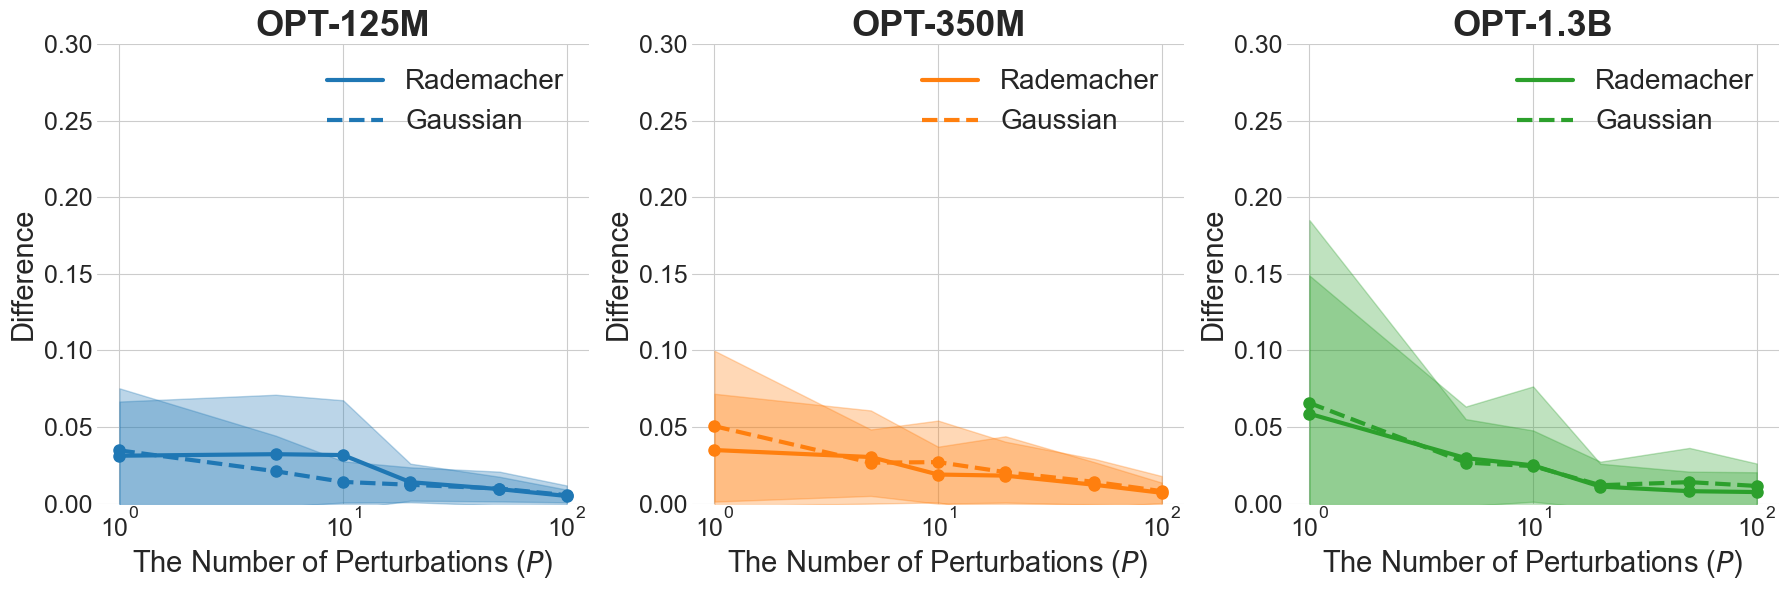

In [7]:
# Store distance statistics for each result
distance_stats = {
    'experiment': [],
    'sample_idx': [],
    'mean_distance': [],
    'std_distance': [],
    'num_perturbations': [],
    'model_size': [],
    'method': []
}

# Process each result file
for result_file in result_files:
    with open(result_file, 'r') as f:
        data = json.load(f)
    
    experiment_name = result_file.parent.name
    
    # Process each sample
    for sample in data['samples']:
        sample_idx = sample['sample_idx']
        sgd_probs = np.array(sample['sgd_probs_history'])  # Shape: (n_iterations, 2)
        zo_probs = np.array(sample['zo_probs_history'])    # Shape: (n_iterations, 2)
        
        # Calculate Euclidean distance: sqrt(sum((zo - sgd)**2, axis=1))
        # This gives us a 1D array of distances, one per iteration
        distances = np.sqrt(np.sum((zo_probs - sgd_probs)**2, axis=1))
        
        # Calculate mean and std of distances
        mean_dist = np.mean(distances)
        std_dist = np.std(distances)
        
        distance_stats['experiment'].append(experiment_name)
        distance_stats['sample_idx'].append(sample_idx)
        distance_stats['mean_distance'].append(mean_dist)
        distance_stats['std_distance'].append(std_dist)
        distance_stats['num_perturbations'].append(extract_num_perturbations(experiment_name))
        distance_stats['model_size'].append(extract_model_size(experiment_name))
        distance_stats['method'].append(extract_method(experiment_name))

# Create DataFrame
distance_df = pd.DataFrame(distance_stats)
distance_df = distance_df.dropna(subset=['num_perturbations', 'model_size', 'method'])

# Group by experiment to get mean and std across samples
experiment_distance_stats = distance_df.groupby('experiment').agg({
    'mean_distance': ['mean', 'std'],
    'std_distance': 'mean',
    'num_perturbations': 'first',
    'model_size': 'first',
    'method': 'first'
}).reset_index()

# Flatten column names
experiment_distance_stats.columns = ['experiment', 'mean_distance_mean', 'mean_distance_std', 
                                     'std_distance_mean', 'num_perturbations', 'model_size', 'method']

# Order models in specific order: 125m, 350m, 1.3b
unique_model_sizes = ['125m', '350m', '1.3b']
# Filter to only include models that exist in the data
unique_model_sizes = [m for m in unique_model_sizes if m in experiment_distance_stats['model_size'].unique()]

# Update color_map to match the new order
color_map = {model: plt.cm.tab10(i) for i, model in enumerate(unique_model_sizes)}

# Function to map method names for display
def get_method_label(method):
    if method == 'bernoulli':
        return 'Rademacher'
    elif method == 'gaussian':
        return 'Gaussian'
    else:
        return method.capitalize()

# Import Line2D for custom legend handles
from matplotlib.lines import Line2D

# Create visualization
fig, axes = plt.subplots(1, len(unique_model_sizes), figsize=(6*len(unique_model_sizes), 6))

if len(unique_model_sizes) == 1:
    axes = [axes]

sns.set_style("whitegrid")
for idx, model_size in enumerate(unique_model_sizes):
    ax = axes[idx]
    model_data = experiment_distance_stats[experiment_distance_stats['model_size'] == model_size]
    
    for method in unique_methods:
        method_data_subset = model_data[model_data['method'] == method]
        method_data_subset = method_data_subset.sort_values('num_perturbations')
        
        if len(method_data_subset) > 0:
            x = method_data_subset['num_perturbations']
            y_mean = method_data_subset['mean_distance_mean']
            y_std = method_data_subset['mean_distance_std']
            
            # Plot mean as main points
            ax.plot(x, y_mean, marker='o', linewidth=3, markersize=8,
                   label=get_method_label(method), 
                   linestyle=line_styles.get(method, '-'),
                   color=color_map[model_size])
            
            # Plot shadow using ±1.28 std
            ax.fill_between(x, y_mean - 1.28 * y_std, y_mean + 1.28 * y_std, 
                           alpha=0.3, color=color_map[model_size])
    
    ax.set_xlabel('The Number of Perturbations ($P$)', fontsize=21)
    ax.set_ylabel('Difference', fontsize=21)
    ax.set_title(f'OPT-{model_size}'.upper(), fontsize=26, fontweight='bold')
    ax.tick_params(axis='both', labelsize=18)
    
    # Create custom legend with only lines (no markers)
    handles, labels = ax.get_legend_handles_labels()
    # Create new handles with only lines
    new_handles = []
    for handle, label in zip(handles, labels):
        # Get the color and linestyle from the original handle
        color = handle.get_color()
        linestyle = handle.get_linestyle()
        # Create a new line handle without marker
        new_handle = Line2D([0], [0], color=color, linestyle=linestyle, linewidth=3)
        new_handles.append(new_handle)
    ax.legend(new_handles, labels, fontsize=20)
    
    # Add grid to both axes
    ax.grid(True)
    ax.set_xscale('log')
    ax.set_ylim(0, 0.3)
    

plt.tight_layout()
# plt.savefig('l2_difference_zo_fo.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


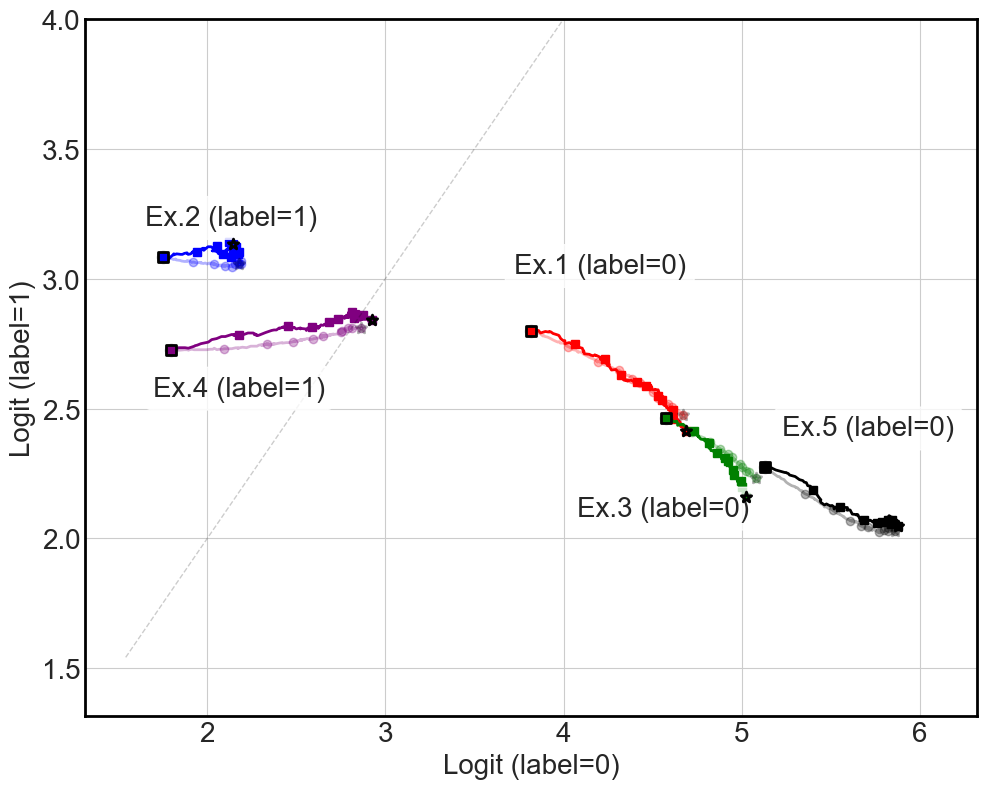

In [56]:
# Plot logit trajectories: logit(label=0) vs logit(label=1) - Combined
# Load the same experiment data
experiment_path = '../../results/text_classification/dynamics_experiments/01_21_2026/opt-125m_gaussian_100/results_22_01_2026_05_02.json'
with open(experiment_path, 'r') as f:
    data = json.load(f)

# Create a single figure with all examples combined
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Color palette for 5 examples
colors = [
        'red', 'blue', 'green', 'purple', 'black'
]

font_size = 20

example_legend_offsets = [
        (-0.1, 0.2),
        (-0.1, 0.1),
        (-0.5, -0.4),
        (-0.1, -0.2),
        (0.1, 0.1)
]

for sample_idx in range(5):
    sample = data['samples'][sample_idx]
    sgd_logits = np.array(sample['sgd_logits_history'])  # Shape: (n_iterations, 2)
    zo_logits = np.array(sample['zo_logits_history'])    # Shape: (n_iterations, 2)
    
    # Extract logit(label=0) and logit(label=1) for each method
    sgd_logit0 = sgd_logits[:, 0]  # logit(label=0) for SGD
    sgd_logit1 = sgd_logits[:, 1]  # logit(label=1) for SGD
    zo_logit0 = zo_logits[:, 0]    # logit(label=0) for ZO
    zo_logit1 = zo_logits[:, 1]     # logit(label=1) for ZO
    
    # Get true label from raw_sentence
    true_label = sample.get('raw_sentence', {}).get('label', 'N/A')
    color = colors[sample_idx]
    
    # Create marker positions (every 20 data points)
    marker_positions = np.arange(0, len(sgd_logit0), 20)
    
    # Plot FO (SGD) trajectory with 0.3 alpha, markers every 20 points
    ax.plot(sgd_logit0, sgd_logit1, label=f'Example {sample_idx + 1} FO (label={true_label})', linewidth=2, color=color, alpha=0.3, 
            marker='o', markevery=marker_positions, markersize=6)
    
    # Plot ZO trajectory with solid line, markers every 20 points
    ax.plot(zo_logit0, zo_logit1, label=f'Example {sample_idx + 1} ZO (label={true_label})', linewidth=2, color=color, alpha=1.0, 
            marker='s', markevery=marker_positions, markersize=6)
    
    # Mark start and end points for FO
    ax.scatter(sgd_logit0[0], sgd_logit1[0], color=color, s=60, marker='o', edgecolors='black', 
               linewidths=2, zorder=5, alpha=0.3)
    ax.scatter(sgd_logit0[-1], sgd_logit1[-1], color=color, s=60, marker='*', edgecolors='black', 
               linewidths=2, zorder=5, alpha=0.3)
    
    # Mark start and end points for ZO
    ax.scatter(zo_logit0[0], zo_logit1[0], color=color, s=60, marker='s', edgecolors='black', 
               linewidths=2, zorder=5, alpha=1.0)
    ax.scatter(zo_logit0[-1], zo_logit1[-1], color=color, s=60, marker='*', edgecolors='black', 
               linewidths=2, zorder=5, alpha=1.0)
    
    # Add text label next to starting point
    ax.text(zo_logit0[0] + example_legend_offsets[sample_idx][0], zo_logit1[0] + example_legend_offsets[sample_idx][1], f'Ex.{sample_idx + 1} (label={true_label})', 
            fontsize=font_size, ha='left', va='bottom', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Logit (label=0)', fontsize=font_size)
ax.set_ylabel('Logit (label=1)', fontsize=font_size)
ax.grid(True)
ax.tick_params(axis='both', labelsize=font_size)

# Add outline to the chart
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor('black')

# Add diagonal line (logit(label=0) = logit(label=1))
# Calculate after all plots are drawn
xlim = ax.get_xlim()
ylim = ax.get_ylim()
diag_min = min(xlim[0], ylim[0])
diag_max = max(xlim[1], ylim[1])
ax.plot([diag_min, diag_max], [diag_min, diag_max], 'k--', alpha=0.2, linewidth=1)
ax.set_ylim(ymax=4)

plt.tight_layout()
plt.show()